In [ ]:
import h5py
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import json, os, warnings
warnings.filterwarnings('ignore')

CMU_H5   = '/kaggle/input/datasets/kmader/cmu-mocap/cmu_processed.h5'
CMU_META = '/kaggle/input/datasets/kmader/cmu-mocap/cmu_meta.csv'

In [ ]:
with h5py.File(CMU_H5, 'r') as f:
    print("Top-level keys:", list(f.keys()))
    # Drill one level to understand the shape
    first_key = list(f.keys())[0]
    print(f"\nFirst key: '{first_key}'")
    print("Sub-keys:", list(f[first_key].keys()))
    # Check shape of first sequence
    sub = list(f[first_key].keys())[0]
    data = f[first_key][sub][:]
    print(f"\nSequence shape: {data.shape}")
    print("Interpretation: (n_frames, n_joints * 3) or (n_frames, n_joints, 3)")

Top-level keys: ['01_01-0', '01_01-1', '01_02-0', '01_02-1', '01_03-0', '01_03-1', '01_04-0', '01_04-1', '01_05-0', '01_05-1', '01_06-0', '01_06-1', '01_07-0', '01_07-1', '01_08-0', '01_08-1', '01_09-0', '01_09-1', '01_10-0', '01_10-1', '01_11-0', '01_11-1', '01_12-0', '01_12-1', '01_13-0', '01_13-1', '01_14-0', '01_14-1', '02_01-0', '02_01-1', '02_02-0', '02_02-1', '02_03-0', '02_03-1', '02_04-0', '02_04-1', '02_05-0', '02_05-1', '02_06-0', '02_06-1', '02_07-0', '02_07-1', '02_08-0', '02_08-1', '02_09-0', '02_09-1', '02_10-0', '02_10-1', '03_01-0', '03_01-1', '03_02-0', '03_02-1', '03_03-0', '03_03-1', '03_04-0', '03_04-1', '05_01-0', '05_01-1', '05_02-0', '05_02-1', '05_03-0', '05_03-1', '05_04-0', '05_04-1', '05_05-0', '05_05-1', '05_06-0', '05_06-1', '05_07-0', '05_07-1', '05_08-0', '05_08-1', '05_09-0', '05_09-1', '05_10-0', '05_10-1', '05_11-0', '05_11-1', '05_12-0', '05_12-1', '05_13-0', '05_13-1', '05_14-0', '05_14-1', '05_15-0', '05_15-1', '05_16-0', '05_16-1', '05_17-0', '05_

In [ ]:
meta = pd.read_csv(CMU_META)
print(meta.head(10))
print("\nAll unique action descriptions:")
print(meta['activity_description'].value_counts().head(40))

                                         path  Subject  Activity  \
0  CMU_Mocap/all_asfamc/subjects/22/22_21.amc       22        21   
1  CMU_Mocap/all_asfamc/subjects/22/22_09.amc       22         9   
2  CMU_Mocap/all_asfamc/subjects/22/22_08.amc       22         8   
3  CMU_Mocap/all_asfamc/subjects/22/22_20.amc       22        20   
4  CMU_Mocap/all_asfamc/subjects/22/22_22.amc       22        22   
5  CMU_Mocap/all_asfamc/subjects/22/22_23.amc       22        23   
6  CMU_Mocap/all_asfamc/subjects/22/22_18.amc       22        18   
7  CMU_Mocap/all_asfamc/subjects/22/22_02.amc       22         2   
8  CMU_Mocap/all_asfamc/subjects/22/22_24.amc       22        24   
9  CMU_Mocap/all_asfamc/subjects/22/22_03.amc       22         3   

                                  asf_path full_id  \
0  CMU_Mocap/all_asfamc/subjects/22/22.asf   22_21   
1  CMU_Mocap/all_asfamc/subjects/22/22.asf   22_09   
2  CMU_Mocap/all_asfamc/subjects/22/22.asf   22_08   
3  CMU_Mocap/all_asfamc/subjects/22

In [ ]:
RELEVANT_KEYWORDS = [
    'jump', 'run', 'walk', 'kick', 'basketball',
    'soccer', 'squat', 'lunge', 'leap', 'sprint',
    'cutting', 'jog', 'land'
]

def is_relevant(description):
    if pd.isna(description):
        return False
    desc_lower = str(description).lower()
    return any(kw in desc_lower for kw in RELEVANT_KEYWORDS)

relevant_meta = meta[meta['activity_description'].apply(is_relevant)].reset_index(drop=True)
print(f"Total sequences: {len(meta)}")
print(f"Relevant sequences: {len(relevant_meta)}")
print("\nSelected action types:")
print(relevant_meta['activity_description'].value_counts())

Total sequences: 2401
Relevant sequences: 973

Selected action types:
activity_description
walk                       81
walk on uneven terrain     37
Jump                       30
basketball signals         16
run/jog                    16
                           ..
Walk, mope around           1
Walk digital 8              1
Punch and kick              1
Walk figure 8               1
Walk up and down stairs     1
Name: count, Length: 404, dtype: int64


In [ ]:
JOINT_MAP = {
    'root':       0,
    'lhipjoint':  1,
    'lfemur':     2,   # left thigh / upper leg
    'ltibia':     3,   # left lower leg
    'lfoot':      4,
    'ltoes':      5,
    'rhipjoint':  6,
    'rfemur':     7,
    'rtibia':     8,
    'rfoot':      9,
    'rtoes':      10,
    'lowerback':  11,
    'upperback':  12,
    'thorax':     13,
    'lowerneck':  14,
    'upperneck':  15,
    'head':       16,
    'lclavicle':  17,
    'lhumerus':   18,
    'lradius':    19,
    'lwrist':     20,
    'lhand':      21,
    'lfingers':   22,
    'lthumb':     23,
    'rclavicle':  24,
    'rhumerus':   25,
    'rradius':    26,
    'rwrist':     27,
    'rhand':      28,
    'rfingers':   29,
    'rthumb':     30,
}

# Biomechanically meaningful joints for our features
# hip = femur joint (top of thigh), knee = tibia joint (bottom of thigh), ankle = foot
LANDMARKS = {
    'l_hip':      'LeftUpLeg',
    'l_knee':     'LeftLeg',
    'l_ankle':    'LeftFoot',
    'r_hip':      'RightUpLeg',
    'r_knee':     'RightLeg',
    'r_ankle':    'RightFoot',
    'l_shoulder': 'LeftArm',
    'r_shoulder': 'RightArm',
    'spine':      'Spine3',
    'root':       'root',       # pelvis — used as trunk base
}

def load_joints_3d(f, seq_key):
    """
    Load only the joints we need from the H5 file.
    Returns dict: { landmark_name: np.array (n_frames, 3) }
    """
    joints = {}
    for name, h5_key in LANDMARKS.items():
        joints[name] = f[seq_key][h5_key][:]   # (n_frames, 3)
    return joints

In [ ]:
from scipy.signal import savgol_filter
import numpy as np

def angle_between(a, b, c):
    """
    Angle at joint b formed by vectors b→a and b→c.
    a, b, c: (n_frames, 3)
    Returns: (n_frames,) in degrees
    """
    ba = a - b
    bc = c - b
    dot = np.einsum('ij,ij->i', ba, bc)
    norm = np.linalg.norm(ba, axis=1) * np.linalg.norm(bc, axis=1)
    norm = np.clip(norm, 1e-8, None)
    cos_angle = np.clip(dot / norm, -1.0, 1.0)
    return np.degrees(np.arccos(cos_angle))

def smooth(signal, window=7, poly=2):
    if len(signal) < window:
        return signal
    return savgol_filter(signal, window_length=window, polyorder=poly)

def compute_3d_features(joints):
    """
    joints: dict of { landmark_name: (n_frames, 3) }
    Returns: dict of feature arrays, each (n_frames,)
    """
    l_knee_raw  = angle_between(joints['l_hip'],  joints['l_knee'],  joints['l_ankle'])
    r_knee_raw  = angle_between(joints['r_hip'],  joints['r_knee'],  joints['r_ankle'])
    l_hip_raw   = angle_between(joints['l_shoulder'], joints['l_hip'], joints['l_knee'])
    r_hip_raw   = angle_between(joints['r_shoulder'], joints['r_hip'], joints['r_knee'])

    # Trunk lean: angle of spine→root vector from vertical (Y axis)
    spine_vec   = joints['spine'] - joints['root']
    vertical    = np.array([0, 1, 0])
    dot         = np.dot(spine_vec, vertical)
    norm        = np.linalg.norm(spine_vec, axis=1).clip(1e-8)
    trunk_raw   = np.degrees(np.arccos(np.clip(dot / norm, -1, 1)))

    # Smooth everything before derivatives
    l_knee  = smooth(l_knee_raw)
    r_knee  = smooth(r_knee_raw)
    l_hip   = smooth(l_hip_raw)
    r_hip   = smooth(r_hip_raw)
    trunk   = smooth(trunk_raw)

    # Asymmetry and velocities
    asymmetry   = np.abs(l_knee - r_knee)
    l_knee_vel  = np.gradient(l_knee)
    r_knee_vel  = np.gradient(r_knee)

    return {
        'l_knee_angle': l_knee,
        'r_knee_angle': r_knee,
        'l_hip_angle':  l_hip,
        'r_hip_angle':  r_hip,
        'trunk_lean':   trunk,
        'asymmetry':    asymmetry,
        'l_knee_vel':   l_knee_vel,
        'r_knee_vel':   r_knee_vel,
    }


In [ ]:

THRESHOLDS = {
    'knee_valgus':  (10.0, 20.0),   
    'asymmetry':    (5.0,  15.0), 
    'trunk_lean':   (10.0, 25.0),   
    'knee_vel':     (150.0, 300.0), # deg/s at peak velocity
}

WEIGHTS = {
    'knee':      0.40,
    'asymmetry': 0.30,
    'trunk':     0.15,
    'velocity':  0.15,
}

def normalize_subscore(value, safe_max, risk_min):
    """Map value to 0-1. Below safe_max = 0, above risk_min = 1, linear between."""
    if value <= safe_max:
        return 0.0
    if value >= risk_min:
        return 1.0
    return (value - safe_max) / (risk_min - safe_max)

def compute_composite_label(features_window):
    """
    features_window: dict of feature arrays, each (30,)
    Returns: composite score (float), class (str)
    """
    knee_deviation = np.mean(np.maximum(
        np.abs(180 - features_window['l_knee_angle']),  
        np.abs(180 - features_window['r_knee_angle'])
    ))
    asym_mean  = np.mean(features_window['asymmetry'])
    trunk_mean = np.mean(features_window['trunk_lean'])
    vel_peak   = np.max(np.abs(features_window['l_knee_vel']) + np.abs(features_window['r_knee_vel'])) / 2

    s_knee  = normalize_subscore(knee_deviation,*THRESHOLDS['knee_valgus'])
    s_asym  = normalize_subscore(asym_mean,*THRESHOLDS['asymmetry'])
    s_trunk = normalize_subscore(trunk_mean,*THRESHOLDS['trunk_lean'])
    s_vel   = normalize_subscore(vel_peak,*THRESHOLDS['knee_vel'])

    composite = (
        WEIGHTS['knee']* s_knee+
        WEIGHTS['asymmetry']* s_asym+
        WEIGHTS['trunk']* s_trunk+
        WEIGHTS['velocity']* s_vel
    )

    if composite <= 0.33:
        risk_class = 'Low'
    elif composite <= 0.66:
        risk_class = 'Medium'
    else:
        risk_class = 'High'

    return composite, risk_class, {
        's_knee': s_knee, 's_asym': s_asym,
        's_trunk': s_trunk, 's_vel': s_vel
    }

In [ ]:
def project_to_2d(joints, view='front'):
    if view == 'front':
        return {name: arr[:, :2] for name, arr in joints.items()}   
    elif view == 'side':
        return {name: arr[:, 1:] for name, arr in joints.items()}   
    else:
        raise ValueError("view must be 'front' or 'side'")

def angle_between_2d(a, b, c):
    """Angle at b from vectors b->a and b->c in 2D."""
    v1 = a - b
    v2 = c - b
    cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8)
    return np.degrees(np.arccos(np.clip(cos_angle, -1.0, 1.0)))

def compute_2d_features(joints_2d):
    """
    joints_2d: dict of { landmark_name: (n_frames, 2) }
    Returns: feature dict — these become the LSTM input features
    """
    n = next(iter(joints_2d.values())).shape[0]   # get n_frames from any entry

    l_hip= joints_2d['l_hip']
    l_knee= joints_2d['l_knee']
    l_ankle= joints_2d['l_ankle']
    r_hip= joints_2d['r_hip']
    r_knee= joints_2d['r_knee']
    r_ankle = joints_2d['r_ankle']
    l_shoulder = joints_2d['l_shoulder']
    r_shoulder = joints_2d['r_shoulder']
    pelvis= joints_2d['root']            

    l_knee_angle = np.array([angle_between_2d(l_hip[i], l_knee[i], l_ankle[i]) for i in range(n)])
    r_knee_angle = np.array([angle_between_2d(r_hip[i], r_knee[i], r_ankle[i]) for i in range(n)])

    mid_shoulder = (l_shoulder + r_shoulder) / 2
    l_hip_angle  = np.array([angle_between_2d(mid_shoulder[i], l_hip[i], l_knee[i]) for i in range(n)])
    r_hip_angle  = np.array([angle_between_2d(mid_shoulder[i], r_hip[i], r_knee[i]) for i in range(n)])

    trunk_vec   = mid_shoulder - pelvis
    vertical_2d = np.array([0, 1])
    trunk_lean  = np.array([
        np.degrees(np.arccos(np.clip(
            np.dot(trunk_vec[i] / (np.linalg.norm(trunk_vec[i]) + 1e-8), vertical_2d), -1, 1
        ))) for i in range(n)
    ])

    asymmetry = np.abs(l_knee_angle - r_knee_angle)

    def smooth(x):
        if len(x) < 7: return x
        return savgol_filter(x, window_length=7, polyorder=2)

    l_knee_vel = np.gradient(smooth(l_knee_angle))
    r_knee_vel = np.gradient(smooth(r_knee_angle))

    return {
        'l_knee_angle': l_knee_angle,
        'r_knee_angle': r_knee_angle,
        'l_hip_angle':  l_hip_angle,
        'r_hip_angle':  r_hip_angle,
        'trunk_lean':   trunk_lean,
        'asymmetry':    asymmetry,
        'l_knee_vel':   l_knee_vel,
        'r_knee_vel':   r_knee_vel,
    }

In [ ]:
WINDOW_SIZE  = 30
STEP_SIZE    = 15   # 50% overlap
FEATURE_KEYS = ['l_knee_angle', 'r_knee_angle', 'l_hip_angle',
                'r_hip_angle', 'trunk_lean', 'asymmetry',
                'l_knee_vel', 'r_knee_vel']

cmu_samples = []

with h5py.File(CMU_H5, 'r') as f:
    all_seq_keys = list(f.keys())
    print(f"Total sequences in H5: {len(all_seq_keys)}")

    for seq_key in all_seq_keys:

        # Check all required joints exist in this sequence
        available = list(f[seq_key].keys())
        if not all(h5_key in available for h5_key in LANDMARKS.values()):
            print(f"  Skipping {seq_key} — missing joints")
            continue

        n_frames = f[seq_key]['LeftLeg'].shape[0]
        if n_frames < WINDOW_SIZE:
            continue

        # Load joints as dict of (n_frames, 3) arrays
        joints = load_joints_3d(f, seq_key)

        # Compute 3D ground truth features (these become labels)
        feats_3d = compute_3d_features(joints)

        for view in ['front', 'side']:
            joints_2d = project_to_2d(joints, view=view)   
            feats_2d  = compute_2d_features(joints_2d)     

            for start in range(0, n_frames - WINDOW_SIZE + 1, STEP_SIZE):
                end = start + WINDOW_SIZE

                # Label from 3D ground truth
                window_3d = {k: feats_3d[k][start:end] for k in FEATURE_KEYS}
                composite, risk_class, sub_scores = compute_composite_label(window_3d)

                # Input features from 2D projection
                window_2d = np.stack(
                    [feats_2d[k][start:end] for k in FEATURE_KEYS],
                    axis=1   # (30, 8)
                )

                cmu_samples.append({
                    'features':  window_2d,
                    'label':     risk_class,
                    'score':     composite,
                    'sub_scores': sub_scores,
                    'source':    'CMU',
                    'view':      view,
                    'seq_key':   seq_key,
                })

print(f"\nTotal CMU windows extracted: {len(cmu_samples)}")

Total sequences in H5: 4622

Total CMU windows extracted: 511926


In [ ]:
with h5py.File(CMU_H5, 'r') as f:
    first_seq = list(f.keys())[0]
    print(f"Sequence key: {first_seq}")
    print(f"Sub-keys under it: {list(f[first_seq].keys())}\n")
    for sub_key in f[first_seq].keys():
        item = f[first_seq][sub_key]
        if isinstance(item, h5py.Dataset):
            print(f"  Dataset  '{sub_key}':  shape={item.shape}")
        else:
            print(f"  Group    '{sub_key}':")
            for subsubkey in item.keys():
                print(f"             '{subsubkey}':  shape={item[subsubkey].shape}")

Sequence key: 01_01-0
Sub-keys under it: ['Head', 'Hips', 'LeftArm', 'LeftFoot', 'LeftForeArm', 'LeftLeg', 'LeftUpLeg', 'RightArm', 'RightFoot', 'RightForeArm', 'RightLeg', 'RightUpLeg', 'Spine3', 'lclavicle', 'lfingers', 'lhand', 'lhipjoint', 'lowerneck', 'lthumb', 'ltoes', 'lwrist', 'rclavicle', 'rfingers', 'rhand', 'rhipjoint', 'root', 'rthumb', 'rtoes', 'rwrist', 'upperback', 'upperneck']

  Dataset  'Head':  shape=(1376, 3)
  Dataset  'Hips':  shape=(1376, 3)
  Dataset  'LeftArm':  shape=(1376, 3)
  Dataset  'LeftFoot':  shape=(1376, 3)
  Dataset  'LeftForeArm':  shape=(1376, 3)
  Dataset  'LeftLeg':  shape=(1376, 3)
  Dataset  'LeftUpLeg':  shape=(1376, 3)
  Dataset  'RightArm':  shape=(1376, 3)
  Dataset  'RightFoot':  shape=(1376, 3)
  Dataset  'RightForeArm':  shape=(1376, 3)
  Dataset  'RightLeg':  shape=(1376, 3)
  Dataset  'RightUpLeg':  shape=(1376, 3)
  Dataset  'Spine3':  shape=(1376, 3)
  Dataset  'lclavicle':  shape=(1376, 3)
  Dataset  'lfingers':  shape=(1376, 3)
  D

CMU Label Distribution:
  Low     :     0  (0.0%)
  Medium  : 342530  (66.9%)
  High    : 169396  (33.1%)

Class weights for loss function:
  Low: 1.0000
  Medium: 0.0000
  High: 0.0000


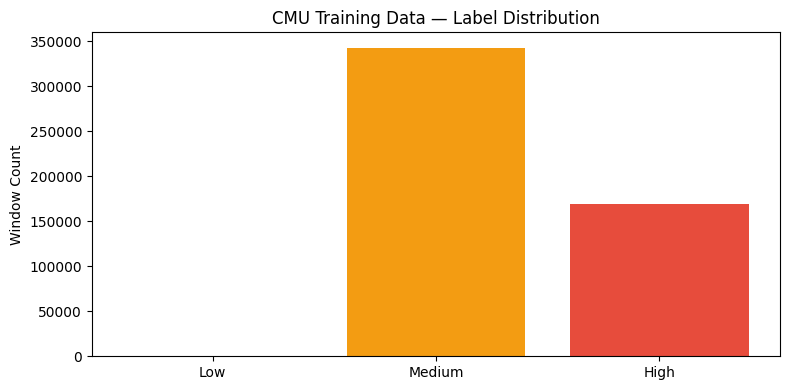

In [ ]:
from collections import Counter

label_counts = Counter(s['label'] for s in cmu_samples)
total = len(cmu_samples)

print("CMU Label Distribution:")
for cls in ['Low', 'Medium', 'High']:
    count = label_counts.get(cls, 0)
    pct   = 100 * count / total
    print(f"  {cls:8s}: {count:5d}  ({pct:.1f}%)")

class_order  = ['Low', 'Medium', 'High']
class_counts = np.array([label_counts.get(c, 1) for c in class_order], dtype=float)
class_weights = total / (len(class_order) * class_counts)
class_weights = class_weights / class_weights.sum()

print(f"\nClass weights for loss function:")
for cls, w in zip(class_order, class_weights):
    print(f"  {cls}: {w:.4f}")

# Plot
plt.figure(figsize=(8, 4))
plt.bar(class_order, [label_counts.get(c, 0) for c in class_order],
        color=['#2ECC71', '#F39C12', '#E74C3C'])
plt.title('CMU Training Data — Label Distribution')
plt.ylabel('Window Count')
plt.tight_layout()
plt.savefig('cmu_label_distribution.png', dpi=120)
plt.show()

In [ ]:

import scipy.io as sio
import glob

PENN_ROOT = '/kaggle/input/datasets/kaushalbora18/penn-action-dataset/Penn_Action'
PENN_LABELS_DIR = os.path.join(PENN_ROOT, 'labels')

# Penn Action joint order (16 joints):
# 0:head, 1:l_shoulder, 2:r_shoulder, 3:l_elbow, 4:r_elbow,
# 5:l_wrist, 6:r_wrist, 7:l_hip, 8:r_hip, 9:l_knee,
# 10:r_knee, 11:l_ankle, 12:r_ankle
PENN_LANDMARKS = {
    'l_hip': 7, 'r_hip': 8,
    'l_knee': 9, 'r_knee': 10,
    'l_ankle': 11, 'r_ankle': 12,
    'l_shoulder': 1, 'r_shoulder': 2,
}

PENN_RELEVANT_ACTIONS = [
    'jumping_jacks', 'jump_rope', 'pull_ups', 'push_ups',
    'squats', 'strumming_guitar',  # remove non-sports
    'baseball_pitch', 'baseball_swing', 'tennis_forehand',
    'tennis_serve', 'golf_swing', 'clean_and_jerk',
    'bench_press', 'bowling', 'strum_guitar'
]

# More targeted — keep only lower-body intensive actions
KEEP_ACTIONS = ['jumping_jacks', 'jump_rope', 'squats',
                'baseball_pitch', 'tennis_forehand', 'tennis_serve']

penn_samples = []
label_files  = sorted(glob.glob(os.path.join(PENN_LABELS_DIR, '*.mat')))
print(f"Found {len(label_files)} Penn Action sequences")

for lf in label_files:
    try:
        mat  = sio.loadmat(lf)
        action = str(mat.get('action', ['unknown'])[0]).strip()

        if action not in KEEP_ACTIONS:
            continue

        # x, y: (n_frames, n_joints) — 2D pixel coordinates
        x = mat['x'].astype(float)   # (n_frames, 13)
        y = mat['y'].astype(float)

        n_frames  = x.shape[0]
        n_joints  = x.shape[1]
        joints_2d = np.stack([x, y], axis=-1)  # (n_frames, 13, 2)

        if n_frames < WINDOW_SIZE:
            continue

        # Map Penn joints to our landmark names
        penn_feats = {}
        l_knee_a, r_knee_a, l_hip_a, r_hip_a = [], [], [], []
        trunk_leans, asymmetries = [], []

        for i in range(n_frames):
            lh = joints_2d[i, PENN_LANDMARKS['l_hip']]
            lk = joints_2d[i, PENN_LANDMARKS['l_knee']]
            la = joints_2d[i, PENN_LANDMARKS['l_ankle']]
            rh = joints_2d[i, PENN_LANDMARKS['r_hip']]
            rk = joints_2d[i, PENN_LANDMARKS['r_knee']]
            ra = joints_2d[i, PENN_LANDMARKS['r_ankle']]
            ls = joints_2d[i, PENN_LANDMARKS['l_shoulder']]
            rs = joints_2d[i, PENN_LANDMARKS['r_shoulder']]

            l_knee_a.append(angle_between_2d(lh, lk, la))
            r_knee_a.append(angle_between_2d(rh, rk, ra))
            l_hip_a.append(angle_between_2d((ls+rs)/2, lh, lk))
            r_hip_a.append(angle_between_2d((ls+rs)/2, rh, rk))
            mid_s = (ls + rs) / 2
            pelvis = (lh + rh) / 2
            tv = mid_s - pelvis
            trunk_leans.append(np.degrees(np.arccos(np.clip(
                np.dot(tv/(np.linalg.norm(tv)+1e-8), np.array([0,1])), -1, 1
            ))))
            asymmetries.append(abs(l_knee_a[-1] - r_knee_a[-1]))

        def smooth(x):
            if len(x) < 7: return np.array(x)
            return savgol_filter(x, window_length=7, polyorder=2)

        l_knee_arr = np.array(l_knee_a)
        r_knee_arr = np.array(r_knee_a)
        l_knee_vel = np.gradient(smooth(l_knee_arr))
        r_knee_vel = np.gradient(smooth(r_knee_arr))

        feats_penn = {
            'l_knee_angle': l_knee_arr,
            'r_knee_angle': r_knee_arr,
            'l_hip_angle':  np.array(l_hip_a),
            'r_hip_angle':  np.array(r_hip_a),
            'trunk_lean':   np.array(trunk_leans),
            'asymmetry':    np.array(asymmetries),
            'l_knee_vel':   l_knee_vel,
            'r_knee_vel':   r_knee_vel,
        }

        for start in range(0, n_frames - WINDOW_SIZE + 1, 15):
            end = start + WINDOW_SIZE
            window = {k: feats_penn[k][start:end] for k in FEATURE_KEYS}
            composite, risk_class, sub_scores = compute_composite_label(window)

            window_arr = np.stack([feats_penn[k][start:end] for k in FEATURE_KEYS], axis=1)

            penn_samples.append({
                'features': window_arr,
                'label': risk_class,
                'score': composite,
                'sub_scores': sub_scores,
                'source': 'Penn_proxy',   # ← flagged as proxy
                'view': 'real',
                'action': action,
            })

    except Exception as e:
        continue

print(f"Penn Action windows extracted: {len(penn_samples)}")
penn_label_counts = Counter(s['label'] for s in penn_samples)
print("Penn Label Distribution:", dict(penn_label_counts))

Found 2326 Penn Action sequences
Penn Action windows extracted: 1652
Penn Label Distribution: {'High': 1220, 'Medium': 209, 'Low': 223}


In [ ]:
def augment_sample(sample):
    """Returns a list of augmented variants of one sample."""
    feats   = sample['features'].copy()  # (30, 8)
    augmented = []

    # 1. Gaussian noise
    noisy = feats + np.random.normal(0, 0.01, feats.shape)
    augmented.append({**sample, 'features': noisy, 'aug': 'noise'})

    # 2. Left-right mirror — swap l/r feature pairs
    # Feature order: l_knee, r_knee, l_hip, r_hip, trunk, asym, l_vel, r_vel
    mirrored = feats.copy()
    mirrored[:, [0,1]] = feats[:, [1,0]]  # swap l/r knee angle
    mirrored[:, [2,3]] = feats[:, [3,2]]  # swap l/r hip angle
    mirrored[:, [6,7]] = feats[:, [7,6]]  # swap l/r knee vel
    augmented.append({**sample, 'features': mirrored, 'aug': 'mirror'})

    # 3. Speed perturbation — resample to 0.8x and 1.2x
    for speed in [0.8, 1.2]:
        n_target  = 30
        n_current = feats.shape[0]
        indices   = np.linspace(0, n_current - 1, int(n_current / speed))
        indices   = np.clip(indices, 0, n_current - 1)
        resampled = np.array([
            np.interp(np.linspace(0, len(indices)-1, n_target),
                      np.arange(len(indices)),
                      indices)
        ])[0]
        resampled_feats = np.array([
            np.interp(np.linspace(0, n_current-1, n_target),
                      np.arange(n_current), feats[:, j])
            for j in range(feats.shape[1])
        ]).T
        augmented.append({**sample, 'features': resampled_feats,
                         'aug': f'speed_{speed}'})

    return augmented

# Temporal jittering is handled at dataset split time (window start ±3 frames)
# Apply augmentation to training samples only — done after split

In [ ]:
from sklearn.model_selection import train_test_split
import pickle

all_samples = cmu_samples + penn_samples
np.random.seed(42)
np.random.shuffle(all_samples)

labels = [s['label'] for s in all_samples]

train_val, test_samples = train_test_split(
    all_samples, test_size=0.15, stratify=labels, random_state=42
)
train_labels = [s['label'] for s in train_val]
train_samples, val_samples = train_test_split(
    train_val, test_size=0.176, stratify=train_labels, random_state=42
    # 0.176 of 85% ≈ 15% of total
)

# Apply augmentation to training set only
augmented_train = []
for s in train_samples:
    augmented_train.append(s)
    augmented_train.extend(augment_sample(s))

print(f"Train (before aug): {len(train_samples)}")
print(f"Train (after aug):  {len(augmented_train)}")
print(f"Validation:         {len(val_samples)}")
print(f"Test (held-out):    {len(test_samples)} — DO NOT TOUCH UNTIL FINAL EVAL")

# Final class weight recompute on augmented training set
aug_label_counts = Counter(s['label'] for s in augmented_train)
aug_total        = len(augmented_train)
class_weights_final = {
    cls: aug_total / (3 * aug_label_counts.get(cls, 1))
    for cls in ['Low', 'Medium', 'High']
}
# Normalize
w_sum = sum(class_weights_final.values())
class_weights_final = {k: v/w_sum for k, v in class_weights_final.items()}
print(f"\nFinal class weights: {class_weights_final}")

# Save
with open('train_samples.pkl', 'wb') as f:
    pickle.dump(augmented_train, f)
with open('val_samples.pkl', 'wb') as f:
    pickle.dump(val_samples, f)
with open('test_samples.pkl', 'wb') as f:
    pickle.dump(test_samples, f)
with open('class_weights.json', 'w') as f:
    json.dump(class_weights_final, f)

print("\nPhase 2 complete. Files saved: train/val/test_samples.pkl, class_weights.json")

Train (before aug): 359709
Train (after aug):  1798545
Validation:         76832
Test (held-out):    77037 — DO NOT TOUCH UNTIL FINAL EVAL

Final class weights: {'Low': 0.99804851171521, 'Medium': 0.0006485856008546943, 'High': 0.0013029026839352026}

Phase 2 complete. Files saved: train/val/test_samples.pkl, class_weights.json
